In [1]:
import os

# For example:
# You could put this at the top of your program
# to set a value for the variable named CENSUS_API_KEY.
os.environ["CENSUS_API_KEY"] = "2d7297910dd1faf19164ab082cdcf9d696523ab0"

# Estimating space- and time-varying transmission rate from data

In [2]:
from epymorph.adrio import us_tiger
from epymorph.data import ipm, mm
from epymorph.geography.us_census import StateScope
import epymorph.initializer as init
from epymorph.rume import SingleStrataRUME
from epymorph.simulation import default_rng
from epymorph.simulator.basic.basic_simulator import BasicSimulator
from epymorph.time import TimeFrame

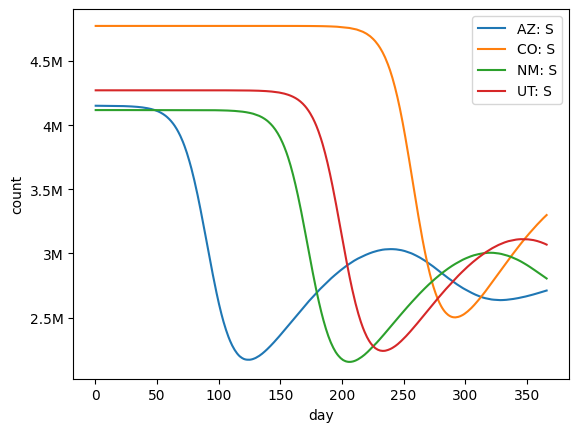

In [5]:
from epymorph.kit import *
from epymorph.adrio import us_tiger


rume = SingleStrataRUME.build(
    ipm=ipm.SIRS(),
    mm=mm.Centroids(),
    init=init.SingleLocation(location=0, seed_size=100),
    scope=StateScope.in_states(["AZ", "CO", "NM", "UT"], year=2020),
    time_frame=TimeFrame.rangex("2020-01-01", "2021-01-01"),
    params={
        "beta": 0.3,
        "gamma": 1/5,
        "xi": 1/90,
        "population": [
            4_151_502, # Arizona
            4_773_714, # Colorado
            4_117_522, # New Mexico
            4_271_616, # Utah
        ],
        "centroid": us_tiger.InternalPoint(),
    },
)

sim = BasicSimulator(rume)
output = sim.run(rng_factory=default_rng(42))

output.plot.line(
    geo=output.rume.scope.select.all(),
    time=output.rume.time_frame.select.all(),
    quantity=output.rume.ipm.select.compartments("S"),
)

# Exercise 1

In [6]:
import numpy as np

from epymorph.kit import *
from epymorph.adrio import acs5
from epymorph.initializer import Proportional

In [ ]:
# Construct a RUME with a scope consisting of four States

states = ["AZ", "CO", "NM", "UT"]

rume = SingleStrataRUME.build(
    ipm=ipm.SIRH(),
    mm=mm.No(),
    scope=StateScope.in_states(states, year=2015),
    init=Proportional(
        ratios=np.broadcast_to(
            np.array([9999, 1, 0,0], dtype=np.int64), shape=(len(states), 4)
        )
    ),
    #time_frame=TimeFrame.of("2022-09-15", 7 * 26 + 1),
    time_frame=TimeFrame.rangex("2022-01-01", "2023-01-01"),
    params={
        "beta": 0.3,  # Placeholder value
        "gamma": 0.2,
        "xi": 1 / 365,
        "hospitalization_prob": 200 / 100_000,
        "hospitalization_duration": 5.0,
        #"population": acs5.Population(),
         "population": np.array([7_000_000, 5_800_000, 2_100_000, 3_300_000]),
    },
)

In [ ]:
#Specify the parameters to be estimated, modeling the beta in each state using geometric Brownian motion with a uniform initial distribution.
#


from epymorph.parameter_fitting.distribution import Uniform
from epymorph.parameter_fitting.utils.parameter_estimation import EstimateParameters
from epymorph.parameter_fitting.dynamics import GeometricBrownianMotion

params_space = {
    "beta": EstimateParameters.TimeVarying(
        distribution=Uniform(a=0.1, b=0.8),
        dynamics=GeometricBrownianMotion(volatility=0.1),
    ),
}

In [ ]:
## Create the observations object using CDC weekly hospitalization data in each state.

from epymorph.adrio.cdc import InfluenzaStateHospitalization
from epymorph.parameter_fitting.likelihood import Poisson
from epymorph.parameter_fitting.utils.observations import ModelLink, Observations
from epymorph.time import EveryNDays

observations = Observations(
    source=InfluenzaStateHospitalization(),
    model_link=ModelLink(
        quantity=rume.ipm.select.events("I->H"),
        time=rume.time_frame.select.all().group(EveryNDays(7)).agg(),
        geo=rume.scope.select.all(),
    ),
    likelihood=Poisson(),
)

In [ ]:
# Specify the filter type (Particle Filter). Note that here is where we could specify the resampler used by the filter, 
#but we’ll just use the default (not localized).

from epymorph.parameter_fitting.filter.particle_filter import ParticleFilter

filter_type = ParticleFilter(num_particles=300)

In [ ]:
#Create the filter simulation object using the RUME.

from epymorph.parameter_fitting.particlefilter_simulation import FilterSimulation

sim = FilterSimulation(
    rume=rume,
    observations=observations,
    filter_type=filter_type,
    params_space=params_space,
)

In [ ]:
# Plot the observational data that was gathered for each US State.

import matplotlib.pyplot as plt

time_axis = range(len(sim.cases))

n_nodes = sim.cases.shape[1]
for i_node in range(n_nodes):
    plt.bar(
        time_axis,
        sim.cases[:, i_node],
        bottom=sim.cases[:, 0:i_node].sum(axis=1),
        label=rume.scope.labels[i_node],
    )

plt.title("Stacked bar chart of weekly hospitalizations")
plt.grid(True)
plt.xlabel("Time (weeks)")
plt.ylabel("Hospitalizations")
plt.legend()
plt.show()

In [ ]:
fig, axs = plt.subplots(2, 2, sharey=True)

axs = np.ravel(axs)
for i_ax in range(len(axs)):
    ax = axs[i_ax]
    ax.bar(
        time_axis,
        sim.cases[:, i_ax],
    )
    ax.set_title(f"Weekly Hosp. in {rume.scope.labels[i_ax]}")
    ax.set_xlabel("Time (weeks)")
    ax.set_ylabel("Hospitalizations")

plt.tight_layout()
plt.show()

In [ ]:
#Run the particle filter.

output = sim.run()

In [ ]:
#Plot the estimated beta for each state.

fig, axs = plt.subplots(2, 2, sharey=True)

key = "beta"
key_quantiles = np.array(output.param_quantiles[key])
t = np.arange(0, len(key_quantiles))

axs = np.ravel(axs)
for i_ax in range(len(axs)):
    ax = axs[i_ax]

    ax.fill_between(
        t,
        key_quantiles[:, 3, i_ax],
        key_quantiles[:, 22 - 3, i_ax],
        facecolor="blue",
        alpha=0.2,
        label="Quantile Range (10th to 90th)",
    )
    ax.fill_between(
        t,
        key_quantiles[:, 6, i_ax],
        key_quantiles[:, 22 - 6, i_ax],
        facecolor="blue",
        alpha=0.4,
        label="Quantile Range (25th to 75th)",
    )

    ax.plot(
        t,
        key_quantiles[:, 11, i_ax],
        color="red",
        label="Median (50th Percentile)",
    )

    ax.set_title(f"Estimate of '{key}' in {rume.scope.labels[i_ax]}")
    ax.set_xlabel("Time (weeks)")
    ax.set_ylabel("Quantiles")
    ax.grid(True)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Respecify the filter type (Particle Filter) to use the ResamplingByNode.
from epymorph.parameter_fitting.utils.resampler import ResamplingByNode

filter_type = ParticleFilter(num_particles=300, resampler=ResamplingByNode)

In [ ]:
#Create the filter simulation object.
sim = FilterSimulation(
    rume=rume,
    observations=observations,
    filter_type=filter_type,
    params_space=params_space,
)

In [ ]:
#Plot the estimated beta for each state.
fig, axs = plt.subplots(2, 2, sharey=True)

key = "beta"
key_quantiles = np.array(output.param_quantiles[key])
t = np.arange(0, len(key_quantiles))

axs = np.ravel(axs)
for i_ax in range(len(axs)):
    ax = axs[i_ax]

    ax.fill_between(
        t,
        key_quantiles[:, 3, i_ax],
        key_quantiles[:, 22 - 3, i_ax],
        facecolor="blue",
        alpha=0.2,
        label="Quantile Range (10th to 90th)",
    )
    ax.fill_between(
        t,
        key_quantiles[:, 6, i_ax],
        key_quantiles[:, 22 - 6, i_ax],
        facecolor="blue",
        alpha=0.4,
        label="Quantile Range (25th to 75th)",
    )

    ax.plot(
        t,
        key_quantiles[:, 11, i_ax],
        color="red",
        label="Median (50th Percentile)",
    )

    ax.set_title(f"Estimate of '{key}' in {rume.scope.labels[i_ax]}")
    ax.set_xlabel("Time (weeks)")
    ax.set_ylabel("Quantiles")
    ax.grid(True)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Plot the hospitalizations expected by the particle filter versus the true hospitalizations in each state.
fig, axs = plt.subplots(2, 2, sharey=True)

axs = np.ravel(axs)
for i_ax in range(len(axs)):
    ax = axs[i_ax]

    ax.plot(
        output.model_data[:, i_ax],
        label="Model Data",
        color="red",
        linestyle="-",
        zorder=10,
        marker="x",
    )

    ax.plot(
        output.true_data[:, i_ax],
        label="True Data",
        color="green",
        linestyle="--",
        zorder=9,
        marker="*",
    )

    ax.set_xlabel("Time (weeks)")
    ax.set_ylabel("Hospitalization")
    ax.set_title(f"Model Data vs True Data in {rume.scope.labels[i_ax]}")
    ax.grid(True)

plt.legend()
plt.tight_layout()
plt.show()